# Train SimCLR for Threshold Typology Clustering

This notebook trains a SimCLR model with geometry-preserving augmentations to learn typology-distinguishing features.

**Expected outcome**: Good t-SNE clustering (Silhouette > 0.3) showing separation of 8 typologies.

## Setup

In [1]:
# Force reload modules
import sys
for mod in ['timesformer_encoder', 'augmentations', 'simclr', 'dataset_simclr', 'config']:
    if mod in sys.modules:
        del sys.modules[mod]

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

from config import get_mae_config
from augmentations import ClipAugmentation
from simclr import create_simclr_model
from dataset_simclr import create_simclr_dataloaders

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0.dev20251029+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## Configuration

In [2]:
# ==========================
# ADJUST THESE SETTINGS
# ==========================

# Data path
DATA_ROOT = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data"

# Training hyperparameters - MATCHING OLD WORKING IMPLEMENTATION
NUM_EPOCHS = 50           # SimCLR typically needs more epochs
BATCH_SIZE = 32           # CHANGED: 128 (was 16) to match old implementation
LEARNING_RATE = 3e-4       # CHANGED: 3e-4 (was 1e-4) to match old implementation
WEIGHT_DECAY = 5e-4        # CHANGED: 5e-4 (was 1e-4) to match old implementation

# SimCLR hyperparameters
TEMPERATURE = 0.1          # NT-Xent temperature (lower = harder negatives)
PROJ_HIDDEN = 512          # Projection head hidden dim
PROJ_OUT = 128             # Projection head output dim

# Data settings
NUM_WORKERS = 4            # Data loading workers (set to 0 if issues)
TRAIN_SPLIT = 0.85         # Train/val split

# Resume training
RESUME_FROM = '../output_simclr/checkpoints/checkpoint_epoch_35.pt'        # Set to checkpoint path to resume (e.g., '../output_simclr/checkpoints/checkpoint_epoch_50.pt')
                          # or None to start fresh

# Output settings
OUTPUT_DIR = '../output_simclr'
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
VIS_DIR = os.path.join(OUTPUT_DIR, 'visualizations')
SAVE_EVERY = 5            # Save checkpoint every N epochs

# Create output directories
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print("Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Temperature: {TEMPERATURE}")
print(f"  Resume from: {RESUME_FROM if RESUME_FROM else 'None (fresh start)'}")
print(f"  Output dir: {OUTPUT_DIR}")

Configuration:
  Epochs: 50
  Batch size: 32
  Learning rate: 0.0003
  Weight decay: 0.0005
  Temperature: 0.1
  Resume from: ../output_simclr/checkpoints/checkpoint_epoch_35.pt
  Output dir: ../output_simclr


## Create Data Loaders

In [3]:
print("="*80)
print("CREATING DATA LOADERS")
print("="*80)
print()

# Create augmentation with geometry-preserving transforms (matching old implementation)
augmentation = ClipAugmentation(
    size=(32, 64),
    brightness=0.15,              # Brightness variation
    blur_prob=0.5,                # 50% chance of blur
    temporal_jitter_prob=0.2,     # 20% chance of temporal shift
    # Note: crop scale is hardcoded to (0.85, 1.0) in ClipTransform
    # flip_prob=0, roll_prob=0, contrast=0 are defaults in make_simclr_transforms()
)

print("Augmentation strategy:")
print("  ✓ Random resized crop (0.85-1.0x, no aspect change)")
print("  ✓ Brightness jitter (±0.15)")
print("  ✓ Gaussian blur (50% prob)")
print("  ✓ Temporal jitter (20% prob, ±1 frame)")
print("  ✗ NO horizontal flip (preserves panorama geometry)")
print("  ✗ NO horizontal roll (preserves spatial structure)")
print("  ✗ NO contrast jitter (preserves depth relationships)")
print()

# Create dataloaders
train_loader, val_loader, train_base_dataset, val_base_dataset = create_simclr_dataloaders(
    data_root=DATA_ROOT,
    augmentation=augmentation,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
)

print(f"Data loaded:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Train sequences: {len(train_loader.dataset)}")
print(f"  Val sequences: {len(val_loader.dataset)}")
print()
print("="*80)

CREATING DATA LOADERS

Augmentation strategy:
  ✓ Random resized crop (0.85-1.0x, no aspect change)
  ✓ Brightness jitter (±0.15)
  ✓ Gaussian blur (50% prob)
  ✓ Temporal jitter (20% prob, ±1 frame)
  ✗ NO horizontal flip (preserves panorama geometry)
  ✗ NO horizontal roll (preserves spatial structure)
  ✗ NO contrast jitter (preserves depth relationships)

Found 8 threshold CSV files
Loaded 1799 threshold sequences from 8 files

TYPOLOGY DISTRIBUTION (before splitting)
  t1: 207 samples (11.5%)
  t2: 244 samples (13.6%)
  t3: 211 samples (11.7%)
  t4: 200 samples (11.1%)
  t5: 222 samples (12.3%)
  t6: 210 samples (11.7%)
  t7: 286 samples (15.9%)
  t8: 219 samples (12.2%)

Stratified split completed:
  Train samples: 1526
  Val samples: 273

TRAIN SET DISTRIBUTION:
  t1: 175 samples (11.5%)
  t2: 207 samples (13.6%)
  t3: 179 samples (11.7%)
  t4: 170 samples (11.1%)
  t5: 188 samples (12.3%)
  t6: 178 samples (11.7%)
  t7: 243 samples (15.9%)
  t8: 186 samples (12.2%)

VAL SET DIS

## Create Model

In [4]:
print("="*80)
print("CREATING MODEL")
print("="*80)
print()

# Get config
config = get_mae_config()

# Create SimCLR model
model = create_simclr_model(
    config,
    proj_hidden=PROJ_HIDDEN,
    proj_out=PROJ_OUT,
    temperature=TEMPERATURE,
)
model = model.to(device)

print(f"Model architecture:")
print(f"  Encoder: TimeSformer (divided space-time attention)")
print(f"  Frames: {config.num_frames}")
print(f"  Hidden size: {config.hidden_size}")
print(f"  Num layers: {config.num_hidden_layers}")
print(f"  Projection: {config.hidden_size} → {PROJ_HIDDEN} → {PROJ_OUT}")
print()
print(f"Parameters:")
print(f"  Total: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Encoder: {sum(p.numel() for p in model.encoder.parameters()):,}")
print()
print("="*80)

CREATING MODEL

Configuration:
  Image size: 32x64
  Patch size: 8x8
  Patches per frame: 32 (4x8)
  Total frames: 7
  Total patches: 224
  Visible patches (~10%): ~22
  Masked patches (~90%): ~201
Model architecture:
  Encoder: TimeSformer (divided space-time attention)
  Frames: 7
  Hidden size: 384
  Num layers: 6
  Projection: 384 → 512 → 128

Parameters:
  Total: 21,597,056
  Encoder: 21,334,272



## Setup Optimizer

In [5]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Learning rate scheduler (cosine annealing)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6,
)

# Load checkpoint if resuming
start_epoch = 0
train_losses = []
val_losses = []
best_val_loss = float('inf')

if RESUME_FROM is not None:
    print(f"Loading checkpoint from: {RESUME_FROM}")
    checkpoint = torch.load(RESUME_FROM)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1  # Start from next epoch
    
    # Load training history if available
    if 'train_losses' in checkpoint:
        train_losses = checkpoint['train_losses']
    if 'val_losses' in checkpoint:
        val_losses = checkpoint['val_losses']
    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']
    
    # Update scheduler to correct position
    for _ in range(start_epoch):
        scheduler.step()
    
    print(f"Resuming from epoch {start_epoch}")
    print(f"Previous best val loss: {best_val_loss:.4f}")
    print(f"Loaded {len(train_losses)} epochs of training history")
else:
    print("Starting fresh training")

print(f"Optimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"Training will run from epoch {start_epoch+1} to {NUM_EPOCHS}")

Loading checkpoint from: ../output_simclr/checkpoints/checkpoint_epoch_35.pt
Resuming from epoch 35
Previous best val loss: 0.0916
Loaded 35 epochs of training history
Optimizer: AdamW (lr=0.0003, wd=0.0005)
Scheduler: CosineAnnealingLR (T_max=50)
Training will run from epoch 36 to 50


C:\Users\shrua\AppData\Local\Temp\ipykernel_18132\1313397420.py:38: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


## Training Loop

**To resume training:**
1. Set `RESUME_FROM` in the Configuration cell to a checkpoint path (e.g., `'../output_simclr/checkpoints/checkpoint_epoch_50.pt'`)
2. Rerun from "Setup Optimizer" cell onwards
3. Training will continue from the saved epoch with full history preserved

In [10]:
print("="*80)
print("TRAINING")
print("="*80)
print()

for epoch in range(start_epoch, NUM_EPOCHS):
    # ============ Training ============
    model.train()
    train_loss_epoch = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        view1 = batch['view1'].to(device)  # (B, 7, 1, 32, 64) - grayscale
        view2 = batch['view2'].to(device)  # (B, 7, 1, 32, 64) - grayscale
        
        # Forward pass
        loss, (h1, h2), (z1, z2) = model(view1, view2)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_epoch += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss_epoch /= len(train_loader)
    train_losses.append(train_loss_epoch)
    
    # ============ Validation ============
    model.eval()
    val_loss_epoch = 0.0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
        for batch in pbar:
            view1 = batch['view1'].to(device)
            view2 = batch['view2'].to(device)
            
            loss, (h1, h2), (z1, z2) = model(view1, view2)
            val_loss_epoch += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    val_loss_epoch /= len(val_loader)
    val_losses.append(val_loss_epoch)
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train Loss: {train_loss_epoch:.4f}")
    print(f"  Val Loss:   {val_loss_epoch:.4f}")
    print(f"  LR:         {current_lr:.2e}")
    
    # Save best model
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
        }, os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
        print(f"  → Best model saved! (val_loss: {val_loss_epoch:.4f})")
    
    # Save periodic checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
        }, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pt'))
        print(f"  → Checkpoint saved (epoch {epoch+1})")
    
    print()

print("="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"Best validation loss: {best_val_loss:.4f}")

# Save final model
torch.save({
    'epoch': NUM_EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_loss': train_losses[-1],
    'val_loss': val_losses[-1],
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
}, os.path.join(CHECKPOINT_DIR, 'final_model.pt'))

# Save encoder only (for downstream tasks)
torch.save(
    model.encoder.state_dict(),
    os.path.join(OUTPUT_DIR, 'timesformer_encoder_simclr.pt')
)
print(f"Encoder saved to: {os.path.join(OUTPUT_DIR, 'timesformer_encoder_simclr.pt')}")

TRAINING



Epoch 36/50 [Train]:   0%|          | 0/47 [00:06<?, ?it/s]

Epoch 36/50 [Val]:   0%|          | 0/9 [00:06<?, ?it/s]

Epoch 36/50:
  Train Loss: 0.0878
  Val Loss:   0.0973
  LR:         2.03e-06



Epoch 37/50 [Train]:   0%|          | 0/47 [00:06<?, ?it/s]

...

Epoch 49/50 [Val]:   0%|          | 0/9 [00:06<?, ?it/s]

Epoch 49/50:
  Train Loss: 0.0992
  Val Loss:   0.0863
  LR:         1.01e-06



Epoch 50/50 [Train]:   0%|          | 0/47 [00:06<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/9 [00:06<?, ?it/s]

Epoch 50/50:
  Train Loss: 0.0712
  Val Loss:   0.0915
  LR:         1.00e-06
  → Checkpoint saved (epoch 50)

TRAINING COMPLETE!
Best validation loss: 0.0785
Encoder saved to: ../output_simclr\timesformer_encoder_simclr.pt


## Visualize Training Curves

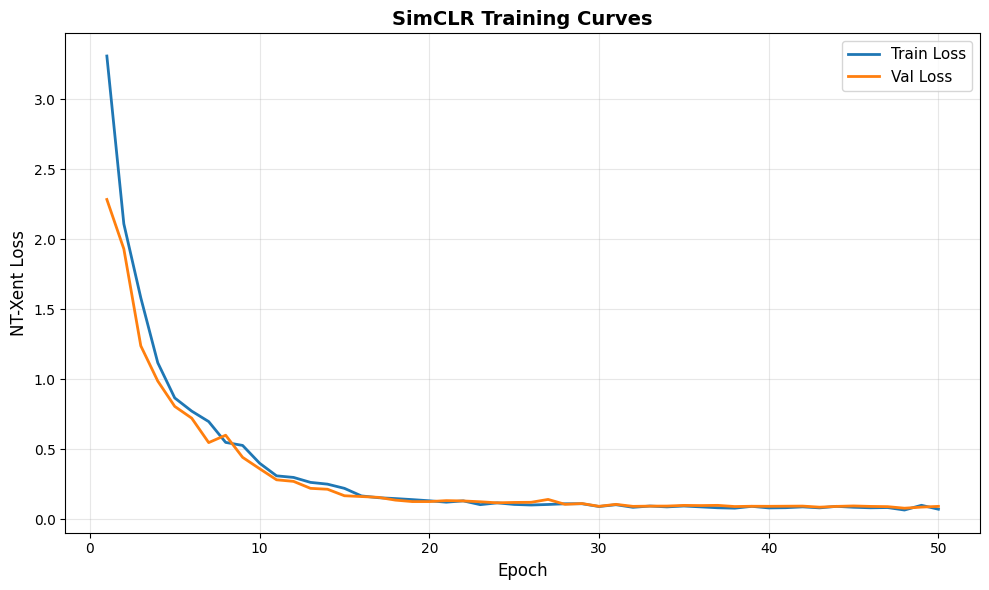

Training curves saved to: ../output_simclr\training_curves.png


In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

epochs = np.arange(1, NUM_EPOCHS + 1)
ax.plot(epochs, train_losses, label='Train Loss', linewidth=2)
ax.plot(epochs, val_losses, label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('NT-Xent Loss', fontsize=12)
ax.set_title('SimCLR Training Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")

## Evaluate Clustering (THE KEY TEST!)

This is the critical evaluation: do the learned embeddings cluster by typology?

In [12]:
print("="*80)
print("CLUSTERING EVALUATION")
print("="*80)
print()

# Load best model
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model (epoch {}, val_loss: {:.4f})".format(
    checkpoint['epoch'], checkpoint['val_loss']))
print()

# Extract embeddings from validation set (no augmentation!)
embeddings = []
labels = []
typology_names_list = []

print("Extracting embeddings from validation set...")
with torch.no_grad():
    for sample in tqdm(val_base_dataset):
        frames = sample['frames'].unsqueeze(0).to(device)  # (1, 7, 1, 32, 64) - grayscale
        h = model.encoder(frames)  # (1, 384)
        embeddings.append(h.cpu().numpy())
        labels.append(sample['typology_label'])
        typology_names_list.append(sample['metadata']['typology'].split('-')[0])

embeddings = np.concatenate(embeddings, axis=0)  # (N, 384)
labels = np.array(labels)  # (N,)

print(f"\nExtracted {len(embeddings)} embeddings")
print(f"Embedding shape: {embeddings.shape}")
print()

# Analyze typology distribution
print("="*80)
print("TYPOLOGY DISTRIBUTION IN VALIDATION SET")
print("="*80)
unique_labels = np.unique(labels)
unique_typologies = sorted(set(typology_names_list))
print(f"Number of unique typology indices: {len(unique_labels)}")
print(f"Unique indices: {unique_labels}")
print(f"Number of unique typology names: {len(unique_typologies)}")
print(f"Unique names: {unique_typologies}")
print()

print("Sample counts per typology:")
for typology in unique_typologies:
    count = sum(1 for t in typology_names_list if t == typology)
    # Find corresponding index
    sample_idx = typology_names_list.index(typology)
    label_idx = labels[sample_idx]
    print(f"  {typology} (label {label_idx}): {count} samples")
print()

if len(unique_labels) < 8:
    print("⚠ WARNING: Validation set only contains {} typologies!".format(len(unique_labels)))
    print("This might be due to train/val split. Consider:")
    print("  1. Checking if all typologies exist in your data")
    print("  2. Adjusting TRAIN_SPLIT to ensure all typologies in validation")
    print("  3. Using stratified split instead of CSV-based split")
    print()
else:
    print("✓ All 8 typologies present in validation set")
    print()

print("="*80)

CLUSTERING EVALUATION

Loaded best model (epoch 47, val_loss: 0.0785)

Extracting embeddings from validation set...


  0%|          | 0/273 [00:00<?, ?it/s]


Extracted 273 embeddings
Embedding shape: (273, 384)

TYPOLOGY DISTRIBUTION IN VALIDATION SET
Number of unique typology indices: 8
Unique indices: [0 1 2 3 4 5 6 7]
Number of unique typology names: 8
Unique names: ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']

Sample counts per typology:
  t1 (label 0): 32 samples
  t2 (label 1): 37 samples
  t3 (label 2): 32 samples
  t4 (label 3): 30 samples
  t5 (label 4): 34 samples
  t6 (label 5): 32 samples
  t7 (label 6): 43 samples
  t8 (label 7): 33 samples

✓ All 8 typologies present in validation set



In [13]:
# Compute t-SNE
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) // 4))
embeddings_2d = tsne.fit_transform(embeddings)
print("t-SNE complete")
print()

# Compute clustering metrics
num_clusters = len(unique_labels)
silhouette = silhouette_score(embeddings, labels)

# Compute K-means clustering to compare predicted vs ground truth
print(f"Running K-means with {num_clusters} clusters...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(embeddings)
ari = adjusted_rand_score(labels, pred_labels)

print("="*80)
print("CLUSTERING METRICS")
print("="*80)
print(f"Number of typologies: {num_clusters}")
print(f"Silhouette Score: {silhouette:.3f} (range: -1 to 1, higher is better)")
print(f"Adjusted Rand Index (ARI): {ari:.3f} (range: 0 to 1, higher is better)")
print()

# Interpret results
print("Silhouette Score interpretation:")
if silhouette > 0.3:
    print("  ✓ EXCELLENT! Silhouette > 0.3 indicates good clustering!")
elif silhouette > 0.1:
    print("  ✓ GOOD! Silhouette > 0.1 shows some clustering structure.")
elif silhouette > 0:
    print("  ~ MARGINAL. Silhouette > 0 but weak clustering.")
else:
    print("  ✗ POOR. Negative silhouette indicates random/overlapping clusters.")
print()

print("ARI interpretation:")
if ari > 0.5:
    print("  ✓ EXCELLENT! ARI > 0.5 indicates strong agreement with typologies!")
elif ari > 0.3:
    print("  ✓ GOOD! ARI > 0.3 shows reasonable clustering.")
elif ari > 0.1:
    print("  ~ MARGINAL. ARI > 0.1 but weak agreement.")
else:
    print("  ✗ POOR. ARI near 0 indicates no clustering structure.")

print("="*80)

Computing t-SNE (this may take a minute)...
t-SNE complete

Running K-means with 8 clusters...
CLUSTERING METRICS
Number of typologies: 8
Silhouette Score: 0.064 (range: -1 to 1, higher is better)
Adjusted Rand Index (ARI): 0.381 (range: 0 to 1, higher is better)

Silhouette Score interpretation:
  ~ MARGINAL. Silhouette > 0 but weak clustering.

ARI interpretation:
  ✓ GOOD! ARI > 0.3 shows reasonable clustering.


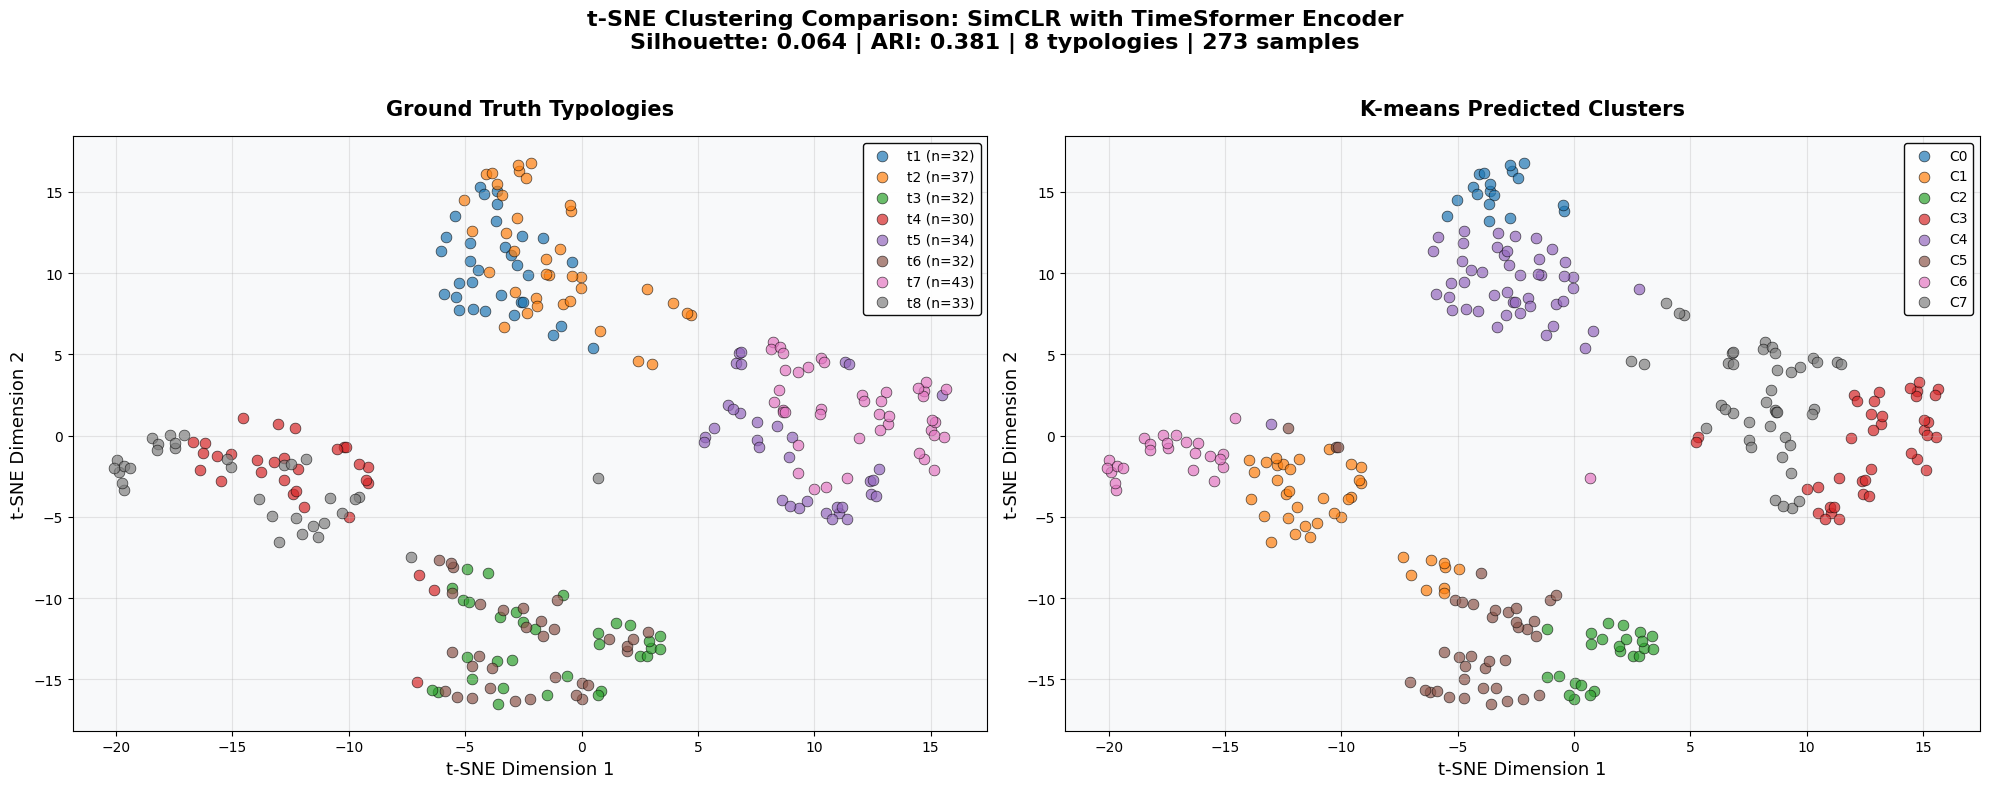


t-SNE comparison plot saved to: ../output_simclr\tsne_clustering_comparison.png

VISUALIZATION GUIDE
LEFT PLOT (Ground Truth):
  - Each color = one typology (e.g., t1, t2, ...)
  - Points close together = similar embeddings
  - If model learned well, same typology should cluster together

RIGHT PLOT (K-means Predictions):
  - Each color = one predicted cluster (C0, C1, ...)
  - Percentage shows cluster purity (% of dominant typology)
  - If clustering is good, each cluster should be dominated by one typology
  - High purity + matching colors ≈ good clustering

ARI = 0.381:
  → Moderate agreement. Some clustering structure learned.


In [14]:
# Visualize t-SNE: Ground Truth vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Create color map based on actual number of typologies
if num_clusters <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, 10))[:num_clusters]
else:
    colors = plt.cm.tab20(np.linspace(0, 1, 20))[:num_clusters]

# Create mapping from label index to typology name
label_to_name = {}
for i, label in enumerate(labels):
    if label not in label_to_name:
        label_to_name[label] = typology_names_list[i]

# LEFT PLOT: Ground Truth Labels
ax = axes[0]
for i, label_idx in enumerate(unique_labels):
    mask = labels == label_idx
    typology_name = label_to_name[label_idx]
    count = np.sum(mask)
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=f'{typology_name} (n={count})',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'Ground Truth Typologies',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# RIGHT PLOT: Predicted Clusters (K-means)
ax = axes[1]
unique_pred_labels = np.unique(pred_labels)
for i, pred_label_idx in enumerate(unique_pred_labels):
    mask = pred_labels == pred_label_idx
    count = np.sum(mask)
    # Find which ground truth typology is most common in this cluster
    gt_labels_in_cluster = labels[mask]
    most_common_gt = np.bincount(gt_labels_in_cluster).argmax()
    most_common_name = label_to_name[most_common_gt]
    purity = np.sum(gt_labels_in_cluster == most_common_gt) / len(gt_labels_in_cluster) * 100
    
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i % len(colors)]],
        label=f'C{pred_label_idx}',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'K-means Predicted Clusters',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# Overall title with metrics
fig.suptitle(
    f't-SNE Clustering Comparison: SimCLR with TimeSformer Encoder\n' + 
    f'Silhouette: {silhouette:.3f} | ARI: {ari:.3f} | {num_clusters} typologies | {len(embeddings)} samples',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clustering_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nt-SNE comparison plot saved to: {os.path.join(OUTPUT_DIR, 'tsne_clustering_comparison.png')}")
print()
print("="*80)
print("VISUALIZATION GUIDE")
print("="*80)
print("LEFT PLOT (Ground Truth):")
print("  - Each color = one typology (e.g., t1, t2, ...)")
print("  - Points close together = similar embeddings")
print("  - If model learned well, same typology should cluster together")
print()
print("RIGHT PLOT (K-means Predictions):")
print("  - Each color = one predicted cluster (C0, C1, ...)")
print("  - Percentage shows cluster purity (% of dominant typology)")
print("  - If clustering is good, each cluster should be dominated by one typology")
print("  - High purity + matching colors ≈ good clustering")
print()
print(f"ARI = {ari:.3f}:")
if ari > 0.7:
    print("  → Strong agreement! Predicted clusters closely match ground truth.")
elif ari > 0.5:
    print("  → Good agreement. Most clusters match their corresponding typology.")
elif ari > 0.3:
    print("  → Moderate agreement. Some clustering structure learned.")
elif ari > 0.1:
    print("  → Weak agreement. Minimal clustering structure.")
else:
    print("  → Poor agreement. Clusters don't align with typologies.")
print("="*80)

## Summary

In [9]:
print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print()
print(f"Model: SimCLR with TimeSformer encoder")
print(f"Epochs trained: {len(train_losses)} (from {start_epoch+1-len(train_losses)+len(train_losses) if start_epoch > 0 else 1} to {NUM_EPOCHS})")
print(f"Best val loss: {best_val_loss:.4f}")
print()
print("Clustering Results:")
print(f"  Silhouette Score: {silhouette:.3f}")
print(f"  Adjusted Rand Index: {ari:.3f}")
print()
print("Output files:")
print(f"  Best model: {os.path.join(CHECKPOINT_DIR, 'best_model.pt')}")
print(f"  Final model: {os.path.join(CHECKPOINT_DIR, 'final_model.pt')}")
print(f"  Encoder: {os.path.join(OUTPUT_DIR, 'timesformer_encoder_simclr.pt')}")
print(f"  Training curves: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")
print(f"  t-SNE comparison: {os.path.join(OUTPUT_DIR, 'tsne_clustering_comparison.png')}")
print()

if silhouette > 0.3 and ari > 0.3:
    print("🎉 SUCCESS! Good clustering achieved!")
    print("Next steps:")
    print("  1. Use encoder for downstream tasks (classification, etc.)")
    print("  2. Fine-tune on labeled data")
    print("  3. Analyze learned features")
elif silhouette > 0.1:
    print("✓ Reasonable clustering, but room for improvement.")
    print("Try:")
    print("  - Training for more epochs")
    print("  - Adjusting temperature (try 0.05 or 0.2)")
    print("  - Stronger augmentations")
else:
    print("⚠ Clustering needs improvement.")
    print("Suggestions:")
    print("  - Check if augmentations preserve geometry")
    print("  - Train for more epochs (200+)")
    print("  - Try different temperatures")
    print("  - Verify data quality")

print()
print("="*80)
print("TO RESUME TRAINING LATER:")
print("="*80)
print("Set RESUME_FROM in the configuration cell to:")
print(f"  RESUME_FROM = '{os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_XX.pt')}'")
print("or")
print(f"  RESUME_FROM = '{os.path.join(CHECKPOINT_DIR, 'best_model.pt')}'")
print("Then rerun from the 'Setup Optimizer' cell onwards.")
print("="*80)

TRAINING SUMMARY

Model: SimCLR with TimeSformer encoder
Epochs trained: 35 (from 36 to 50)
Best val loss: 0.0916

Clustering Results:
  Silhouette Score: 0.063
  Adjusted Rand Index: 0.414

Output files:
  Best model: ../output_simclr\checkpoints\best_model.pt
  Final model: ../output_simclr\checkpoints\final_model.pt
  Encoder: ../output_simclr\timesformer_encoder_simclr.pt
  Training curves: ../output_simclr\training_curves.png
  t-SNE comparison: ../output_simclr\tsne_clustering_comparison.png

⚠ Clustering needs improvement.
Suggestions:
  - Check if augmentations preserve geometry
  - Train for more epochs (200+)
  - Try different temperatures
  - Verify data quality

TO RESUME TRAINING LATER:
Set RESUME_FROM in the configuration cell to:
  RESUME_FROM = '../output_simclr\checkpoints\checkpoint_epoch_XX.pt'
or
  RESUME_FROM = '../output_simclr\checkpoints\best_model.pt'
Then rerun from the 'Setup Optimizer' cell onwards.
